# Stage 2 — SEA-LION Annotation Validation & Train/Val Split

**Steps:**
1. Compute inter-annotator agreement on Pool A (Spearman ρ + Cohen's Kappa)
2. Gate: if Spearman ρ > 0.75, SEA-LION labels are trusted as training signal
3. Split 5,000-image SEA-LION labels → train (4,000) / val (1,000) for ViT fine-tuning

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.metrics import cohen_kappa_score
from pathlib import Path

SCORING_DIR = Path(".")  # run from scoring/
sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Pool A

In [9]:
pool_a = pd.read_excel(SCORING_DIR / "pool_a_177_images.xlsx")

# Drop rows where either score is missing
df = pool_a.dropna(subset=["[SEA-LION] Overall Score", "[HUMAN] Overall Score"]).copy()
df = df.rename(columns={
    "[SEA-LION] Overall Score": "sealion",
    "[HUMAN] Overall Score":   "human",
})

print(f"Pool A rows: {len(pool_a)}  |  usable (both scores present): {len(df)}")
df[["sealion", "human"]].describe().round(2)

Pool A rows: 177  |  usable (both scores present): 177


,sealion,human
count,177.00,177.00
mean,7.18,6.81
std,1.66,1.64
min,3.00,3.00
25%,6.00,6.00
50%,7.75,7.00
75%,8.50,8.00
max,9.25,9.00


## 2. Inter-annotator Agreement

### 2a. Spearman Rank Correlation

In [10]:
rho, pval = stats.spearmanr(df["sealion"], df["human"])
print(f"Spearman ρ = {rho:.4f}  (p = {pval:.2e})")

Spearman ρ = 0.8879  (p = 6.82e-61)


### 2b. Cohen's Kappa (3-class binning)

In [11]:
def bin_score(s):
    """Map 1–10 score to 3 ordinal classes."""
    if s <= 4:
        return 0  # low
    elif s <= 7:
        return 1  # mid
    else:
        return 2  # high

df["sealion_class"] = df["sealion"].apply(bin_score)
df["human_class"]   = df["human"].apply(bin_score)

kappa = cohen_kappa_score(df["human_class"], df["sealion_class"])
kappa_w = cohen_kappa_score(df["human_class"], df["sealion_class"], weights="linear")

print(f"Cohen's Kappa (unweighted): {kappa:.4f}")
print(f"Cohen's Kappa (linear weighted): {kappa_w:.4f}")

Cohen's Kappa (unweighted): 0.6491
Cohen's Kappa (linear weighted): 0.6968


### 2c. Visualisations

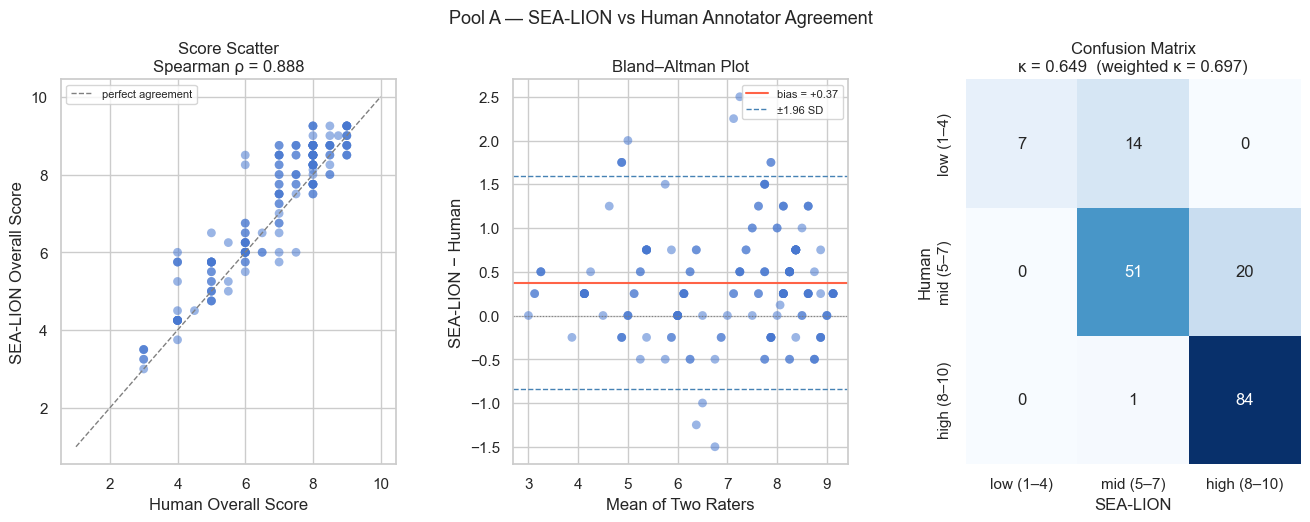

Saved: stage2_agreement_pool_a.png


In [12]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# --- Scatter plot ---
ax1 = fig.add_subplot(gs[0])
ax1.scatter(df["human"], df["sealion"], alpha=0.55, edgecolors="none", s=40)
lims = [1, 10]
ax1.plot(lims, lims, "--", color="gray", lw=1, label="perfect agreement")
ax1.set_xlabel("Human Overall Score")
ax1.set_ylabel("SEA-LION Overall Score")
ax1.set_title(f"Score Scatter\nSpearman ρ = {rho:.3f}")
ax1.legend(fontsize=8)

# --- Bland–Altman ---
mean_score = (df["sealion"] + df["human"]) / 2
diff_score  = df["sealion"] - df["human"]
mean_diff   = diff_score.mean()
sd_diff     = diff_score.std()

ax2 = fig.add_subplot(gs[1])
ax2.scatter(mean_score, diff_score, alpha=0.55, edgecolors="none", s=40)
ax2.axhline(mean_diff, color="tomato",  lw=1.5, label=f"bias = {mean_diff:+.2f}")
ax2.axhline(mean_diff + 1.96*sd_diff, color="steelblue", lw=1, ls="--", label="±1.96 SD")
ax2.axhline(mean_diff - 1.96*sd_diff, color="steelblue", lw=1, ls="--")
ax2.axhline(0, color="gray", lw=0.8, ls=":")
ax2.set_xlabel("Mean of Two Raters")
ax2.set_ylabel("SEA-LION − Human")
ax2.set_title("Bland–Altman Plot")
ax2.legend(fontsize=8)

# --- Confusion matrix (3 classes) ---
ax3 = fig.add_subplot(gs[2])
labels = ["low (1–4)", "mid (5–7)", "high (8–10)"]
cm = pd.crosstab(
    pd.Categorical(df["human_class"],   categories=[0,1,2]),
    pd.Categorical(df["sealion_class"], categories=[0,1,2]),
    rownames=["Human"], colnames=["SEA-LION"],
)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels,
    ax=ax3, cbar=False,
)
ax3.set_title(f"Confusion Matrix\nκ = {kappa:.3f}  (weighted κ = {kappa_w:.3f})")

plt.suptitle("Pool A — SEA-LION vs Human Annotator Agreement", fontsize=13, y=1.02)
plt.savefig(SCORING_DIR / "stage2_agreement_pool_a.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: stage2_agreement_pool_a.png")

### 2d. Per-dataset breakdown

In [13]:
print("Agreement breakdown by dataset:")
for ds, grp in df.groupby("Dataset"):
    r, p = stats.spearmanr(grp["sealion"], grp["human"])
    k = cohen_kappa_score(grp["human_class"], grp["sealion_class"])
    print(f"  {ds:<20}  n={len(grp):>3}  Spearman ρ={r:.3f} (p={p:.2e})  κ={k:.3f}")

Agreement breakdown by dataset:
  bg60k                 n= 93  Spearman ρ=0.646 (p=2.83e-12)  κ=0.557
  ecommerce118k         n= 84  Spearman ρ=0.925 (p=3.81e-36)  κ=0.535


## 3. Gate Decision

In [14]:
THRESHOLD = 0.75

print("=" * 55)
print(f"  Spearman ρ = {rho:.4f}   threshold = {THRESHOLD}")
print("=" * 55)

if rho >= THRESHOLD:
    print("  ✓ PASS — SEA-LION labels are trusted as training signal.")
    print("  Proceeding to train/val split.")
else:
    print("  ✗ FAIL — Agreement too low. Do NOT use SEA-LION labels.")
    print("  Review scoring prompt or collect more human labels before continuing.")
print("=" * 55)

  Spearman ρ = 0.8879   threshold = 0.75
  ✓ PASS — SEA-LION labels are trusted as training signal.
  Proceeding to train/val split.


## 4. Train / Val Split (4,000 / 1,000)

In [15]:
assert rho >= THRESHOLD, "Gate failed — skipping split."

finetune = pd.read_csv(SCORING_DIR / "vit_finetune_5000_labels.csv")
print(f"5k set shape: {finetune.shape}")
print(finetune["dataset"].value_counts())

5k set shape: (5000, 12)
dataset
bg60k            2564
ecommerce118k    2436
Name: count, dtype: int64


In [16]:
# Verify no overlap with Pool A or Pool B
pool_b = pd.read_excel(SCORING_DIR / "pool_b_300_images.xlsx")

ft_keys = set(zip(finetune["dataset"], finetune["filename"]))
pa_keys = set(zip(pool_a["Dataset"].str.lower(), pool_a["Filename"]))
pb_keys = set(zip(pool_b["Dataset"].str.lower(), pool_b["Filename"]))

overlap_a = len(ft_keys & pa_keys)
overlap_b = len(ft_keys & pb_keys)

print(f"5k ∩ Pool A = {overlap_a}  (expected 0)")
print(f"5k ∩ Pool B = {overlap_b}  (expected 0)")
assert overlap_a == 0 and overlap_b == 0, "Overlap detected — check sampling scripts!"

5k ∩ Pool A = 0  (expected 0)
5k ∩ Pool B = 0  (expected 0)


In [17]:
# Stratified split by dataset to preserve bg60k / ecommerce118k balance
SEED     = 42
VAL_FRAC = 0.20  # 1,000 / 5,000

train_parts, val_parts = [], []

for ds, grp in finetune.groupby("dataset"):
    grp = grp.sample(frac=1, random_state=SEED).reset_index(drop=True)
    n_val   = round(len(grp) * VAL_FRAC)
    n_train = len(grp) - n_val
    val_parts.append(grp.iloc[:n_val])
    train_parts.append(grp.iloc[n_val:])
    print(f"  {ds:<20}  train={n_train}  val={n_val}")

train_df = pd.concat(train_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df   = pd.concat(val_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Total: {len(train_df)+len(val_df)}")

  bg60k                 train=2051  val=513
  ecommerce118k         train=1949  val=487

Train: 4000  |  Val: 1000  |  Total: 5000


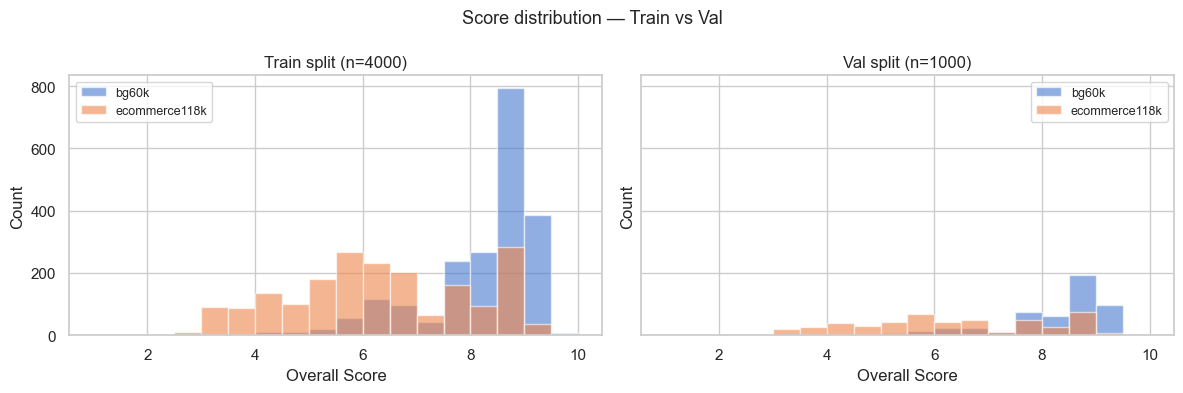

Saved: stage2_train_val_distribution.png


In [18]:
# Score distribution check
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (split_name, split_df) in zip(axes, [("Train", train_df), ("Val", val_df)]):
    for ds, grp in split_df.groupby("dataset"):
        ax.hist(grp["overall_score"], bins=18, alpha=0.6, label=ds, range=(1, 10))
    ax.set_title(f"{split_name} split (n={len(split_df)})")
    ax.set_xlabel("Overall Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("Score distribution — Train vs Val", fontsize=13)
plt.tight_layout()
plt.savefig(SCORING_DIR / "stage2_train_val_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: stage2_train_val_distribution.png")

In [19]:
# Save splits
train_out = SCORING_DIR / "vit_train_4000.csv"
val_out   = SCORING_DIR / "vit_val_1000.csv"

train_df.to_csv(train_out, index=False)
val_df.to_csv(val_out,   index=False)

print(f"Saved: {train_out}  ({len(train_df)} rows)")
print(f"Saved: {val_out}  ({len(val_df)} rows)")

Saved: vit_train_4000.csv  (4000 rows)
Saved: vit_val_1000.csv  (1000 rows)


## 5. Summary

In [20]:
print("=" * 55)
print("  STAGE 2 SUMMARY")
print("=" * 55)
print(f"  Pool A agreement")
print(f"    Spearman ρ       = {rho:.4f}  (threshold {THRESHOLD})")
print(f"    Cohen's κ        = {kappa:.4f}")
print(f"    Cohen's κ (wtd)  = {kappa_w:.4f}")
print(f"    Gate             = {'PASS ✓' if rho >= THRESHOLD else 'FAIL ✗'}")
print()
print(f"  Training set")
print(f"    Train            = {len(train_df):,} images")
print(f"    Val              = {len(val_df):,} images")
print(f"    Score mean (tr)  = {train_df['overall_score'].mean():.2f}")
print(f"    Score mean (val) = {val_df['overall_score'].mean():.2f}")
print("=" * 55)

  STAGE 2 SUMMARY
  Pool A agreement
    Spearman ρ       = 0.8879  (threshold 0.75)
    Cohen's κ        = 0.6491
    Cohen's κ (wtd)  = 0.6968
    Gate             = PASS ✓

  Training set
    Train            = 4,000 images
    Val              = 1,000 images
    Score mean (tr)  = 7.18
    Score mean (val) = 7.20
